# MSCS 634 — Project Deliverable 3
## Classification, Clustering, and Association Rule Mining

This notebook extends the earlier Online Shoppers project using the **UCI Online Shoppers Purchasing Intention Dataset**. Each record represents one e-commerce browsing session. The main supervised-learning objective is to predict **`Revenue`** (whether a session resulted in a purchase).

### Deliverable objectives

1. Build and compare at least two classification models.
2. Tune one classification model with cross-validated hyperparameter search.
3. Evaluate classification using confusion matrices, ROC curves, accuracy, F1 score, and ROC-AUC.
4. Develop and visualize a clustering model.
5. Apply Apriori association rule mining to session-level behavioural indicators.
6. Translate the findings into practical e-commerce recommendations.

> **Reproducibility:** Random seeds are fixed at 42. The notebook saves all figures and result tables into the repository folders.

In [1]:
# Core libraries
from pathlib import Path
from itertools import combinations
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn: preprocessing, supervised learning, evaluation, and clustering
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    silhouette_score,
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')

RANDOM_STATE = 42
DATA_PATH = Path('online_shoppers_intention.csv')
FIGURE_DIR = Path('figures')
OUTPUT_DIR = Path('outputs')
FIGURE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print('Libraries imported and output folders prepared.')

Libraries imported and output folders prepared.


## 1. Load, inspect, and clean the dataset

The original file contains 12,330 sessions and 18 columns. Cleaning removes exact duplicate sessions, standardizes categorical labels, validates logical ranges, and preserves legitimate long browsing sessions rather than treating all large values as errors.

In [2]:
# Load the dataset from the repository root.
df_raw = pd.read_csv(DATA_PATH)

print(f'Raw shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
display(df_raw.head())

inspection = pd.DataFrame({
    'Data Type': df_raw.dtypes.astype(str),
    'Missing Values': df_raw.isna().sum(),
    'Unique Values': df_raw.nunique(dropna=False),
})
display(inspection)
print(f'Exact duplicate rows: {df_raw.duplicated().sum():,}')

Raw shape: 12,330 rows × 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0000,0,0.0000,2,64.0000,0.0000,0.1000,0.0000,0.0000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0000,0,0.0000,2,2.6667,0.0500,0.1400,0.0000,0.0000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0000,0,0.0000,10,627.5000,0.0200,0.0500,0.0000,0.0000,Feb,3,3,1,4,Returning_Visitor,True,False


,Data Type,Missing Values,Unique Values
Administrative,int64,0,27
Administrative_Duration,float64,0,3335
Informational,int64,0,17
Informational_Duration,float64,0,1258
ProductRelated,int64,0,311
ProductRelated_Duration,float64,0,9551
BounceRates,float64,0,1872
ExitRates,float64,0,4777
PageValues,float64,0,2704
SpecialDay,float64,0,6


Exact duplicate rows: 125


In [3]:
# Create a clean working copy.
df = df_raw.copy()

# Standardize text-based categories.
for column in ['Month', 'VisitorType']:
    df[column] = df[column].astype(str).str.strip()
df['Month'] = df['Month'].str[:3].str.title()

# Normalize Boolean fields in case a CSV reader loads them as strings.
def to_boolean(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    return series.astype(str).str.strip().str.lower().map({'true': True, 'false': False})

df['Weekend'] = to_boolean(df['Weekend'])
df['Revenue'] = to_boolean(df['Revenue'])

# Correct impossible negative values and constrain proportion fields to [0, 1].
nonnegative_columns = [
    'Administrative', 'Administrative_Duration', 'Informational',
    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]
for column in nonnegative_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce').clip(lower=0)
for column in ['BounceRates', 'ExitRates', 'SpecialDay']:
    df[column] = df[column].clip(0, 1)

# Remove exact duplicates and reset the row index.
df = df.drop_duplicates().reset_index(drop=True)

print(f'Cleaned shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Rows removed: {len(df_raw) - len(df):,}')
print(f'Remaining missing values: {int(df.isna().sum().sum()):,}')
print('\nClass distribution:')
display(
    df['Revenue'].value_counts().rename_axis('Revenue').to_frame('Sessions')
      .assign(Percentage=lambda x: 100 * x['Sessions'] / len(df))
)

Cleaned shape: 12,205 rows × 18 columns
Rows removed: 125
Remaining missing values: 0

Class distribution:


,Sessions,Percentage
Revenue,,
False,10297,84.3671
True,1908,15.6329


### Feature engineering

The added features summarize browsing volume and quality without using the target:

- `TotalPageCount` and `TotalDuration` measure overall activity.
- `AvgProductTime` measures product-page depth while safely handling zero-page sessions.
- `EngagementScore` is high when both bounce and exit rates are low.
- `ExitBounceGap` captures the difference between exit and bounce behaviour.

In [4]:
# Leakage-safe behavioural feature engineering.
df['TotalPageCount'] = (
    df['Administrative'] + df['Informational'] + df['ProductRelated']
)
df['TotalDuration'] = (
    df['Administrative_Duration']
    + df['Informational_Duration']
    + df['ProductRelated_Duration']
)
df['AvgProductTime'] = (
    df['ProductRelated_Duration']
    / df['ProductRelated'].replace(0, np.nan)
).fillna(0)
df['EngagementScore'] = (1 - df['BounceRates']) * (1 - df['ExitRates'])
df['ExitBounceGap'] = df['ExitRates'] - df['BounceRates']

engineered_columns = [
    'TotalPageCount', 'TotalDuration', 'AvgProductTime',
    'EngagementScore', 'ExitBounceGap'
]
display(df[engineered_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
TotalPageCount,"12,205.0000",34.8932,46.6273,0.0000,9.0000,20.0000,42.0000,746.0000
TotalDuration,"12,205.0000","1,323.4542","2,043.8716",0.0000,231.6667,690.9583,"1,643.9583","69,921.6472"
AvgProductTime,"12,205.0000",38.0191,44.8335,0.0000,17.9792,29.1461,45.2917,"1,411.0000"
EngagementScore,"12,205.0000",0.9409,0.0809,0.6400,0.9381,0.9689,0.9843,1.0000
ExitBounceGap,"12,205.0000",0.0211,0.0202,-0.0656,0.0083,0.0160,0.0275,0.2000


## 2. Classification modelling

Two different tree-based classifiers are developed:

1. **Decision Tree:** interpretable nonlinear baseline.
2. **Random Forest:** ensemble model designed to improve stability and generalization.

Because purchases are the minority class, both models use class weighting. The split is stratified so the purchase rate remains consistent in training and test data. Technical category codes—operating system, browser, region, and traffic type—are treated as categorical rather than continuous measurements.

In [5]:
TARGET = 'Revenue'
CATEGORICAL_COLUMNS = [
    'Month', 'OperatingSystems', 'Browser', 'Region',
    'TrafficType', 'VisitorType', 'Weekend'
]

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int)

# Treat integer identifiers as category labels.
for column in CATEGORICAL_COLUMNS:
    X[column] = X[column].astype(str)

NUMERICAL_COLUMNS = [column for column in X.columns if column not in CATEGORICAL_COLUMNS]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, NUMERICAL_COLUMNS),
    ('categorical', categorical_pipeline, CATEGORICAL_COLUMNS),
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f'Training sessions: {len(X_train):,}')
print(f'Test sessions: {len(X_test):,}')
print(f'Training purchase rate: {y_train.mean():.3%}')
print(f'Test purchase rate: {y_test.mean():.3%}')

Training sessions: 9,764
Test sessions: 2,441
Training purchase rate: 15.629%
Test purchase rate: 15.649%


In [6]:
# Model 1: balanced Decision Tree.
decision_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=7,
        min_samples_leaf=15,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

# Model 2: balanced Random Forest baseline.
random_forest = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

print('Classification pipelines created.')

Classification pipelines created.


### Hyperparameter tuning

The Decision Tree is tuned with **GridSearchCV** using three-fold stratified cross-validation. The search optimizes **F1 score**, not accuracy, because accuracy alone can appear high when the majority class dominates.

Tuned parameters:

- `criterion`: compares Gini impurity and entropy.
- `max_depth`: controls tree complexity.
- `min_samples_split`: sets the minimum observations required to split a node.
- `min_samples_leaf`: prevents leaves from being based on too few sessions.

In [7]:
# Cross-validated hyperparameter tuning for the Decision Tree.
dt_search_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

parameter_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [4, 6, 8, 10],
    'model__min_samples_split': [2, 20],
    'model__min_samples_leaf': [10, 30],
}

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

dt_grid_search = GridSearchCV(
    estimator=dt_search_pipeline,
    param_grid=parameter_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=1,
    return_train_score=True,
)

dt_grid_search.fit(X_train, y_train)
tuned_decision_tree = dt_grid_search.best_estimator_

print(f'Best cross-validated F1: {dt_grid_search.best_score_:.4f}')
print('Best parameters:')
print(json.dumps(dt_grid_search.best_params_, indent=2))

with open(OUTPUT_DIR / 'best_hyperparameters.json', 'w', encoding='utf-8') as file:
    json.dump(dt_grid_search.best_params_, file, indent=2)

Best cross-validated F1: 0.6358
Best parameters:
{
  "model__criterion": "entropy",
  "model__max_depth": 6,
  "model__min_samples_leaf": 30,
  "model__min_samples_split": 2
}


### Classification evaluation

Every model is evaluated on the untouched test set. The positive-class F1 score is emphasized because it balances precision and recall for purchase sessions.

In [8]:
models = {
    'Decision Tree': decision_tree,
    'Random Forest': random_forest,
    'Tuned Decision Tree': tuned_decision_tree,
}

model_predictions = {}
model_probabilities = {}
metric_rows = []
report_frames = []

for model_name, model in models.items():
    # GridSearchCV already fitted the tuned estimator; refitting is harmless and
    # keeps this evaluation loop consistent for every model.
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    model_predictions[model_name] = predictions
    model_probabilities[model_name] = probabilities

    metric_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'F1 Score': f1_score(y_test, predictions),
        'ROC-AUC': roc_auc_score(y_test, probabilities),
    })

    report = pd.DataFrame(
        classification_report(
            y_test,
            predictions,
            target_names=['No Purchase', 'Purchase'],
            output_dict=True,
            zero_division=0,
        )
    ).T.reset_index().rename(columns={'index': 'Class'})
    report.insert(0, 'Model', model_name)
    report_frames.append(report)

classification_metrics = pd.DataFrame(metric_rows).sort_values(
    'F1 Score', ascending=False
).reset_index(drop=True)
classification_reports = pd.concat(report_frames, ignore_index=True)

classification_metrics.to_csv(OUTPUT_DIR / 'classification_metrics.csv', index=False)
classification_reports.to_csv(OUTPUT_DIR / 'classification_reports.csv', index=False)

display(classification_metrics)

,Model,Accuracy,F1 Score,ROC-AUC
0,Decision Tree,0.8472,0.6213,0.9072
1,Tuned Decision Tree,0.8275,0.6148,0.9270
2,Random Forest,0.8947,0.5965,0.9241


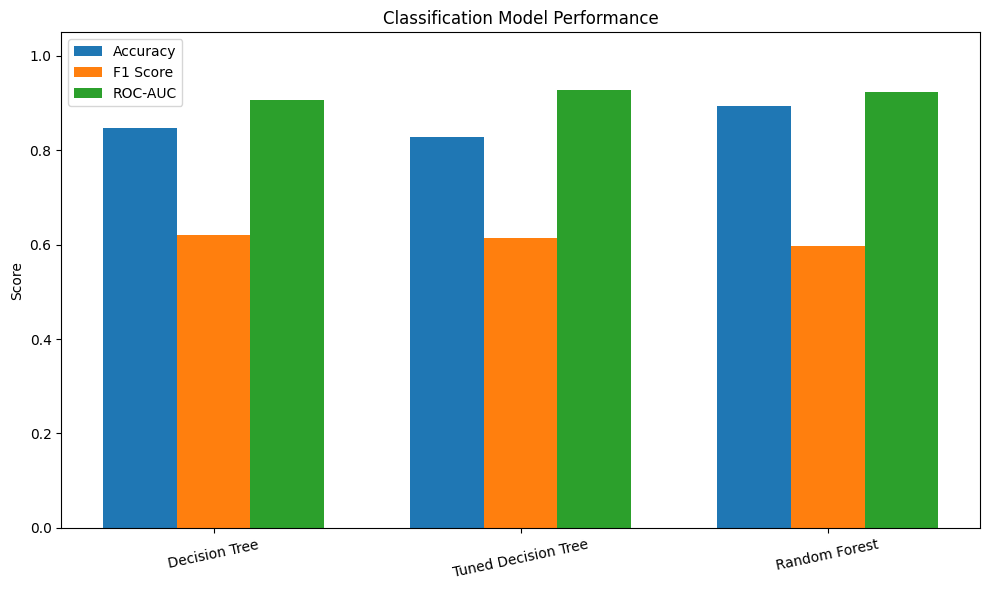

In [9]:
# Model-performance comparison.
metric_names = ['Accuracy', 'F1 Score', 'ROC-AUC']
x = np.arange(len(classification_metrics))
width = 0.24

plt.figure(figsize=(10, 6))
for offset, metric in enumerate(metric_names):
    plt.bar(
        x + (offset - 1) * width,
        classification_metrics[metric],
        width,
        label=metric,
    )
plt.xticks(x, classification_metrics['Model'], rotation=12)
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('Classification Model Performance')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / '01_classification_model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

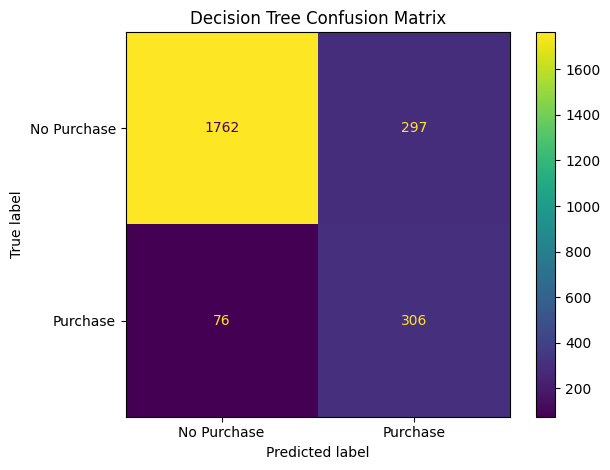

In [10]:
# Confusion matrix: Decision Tree.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_predictions['Decision Tree'],
    display_labels=['No Purchase', 'Purchase'],
    values_format='d',
)
plt.title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '02_decision_tree_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

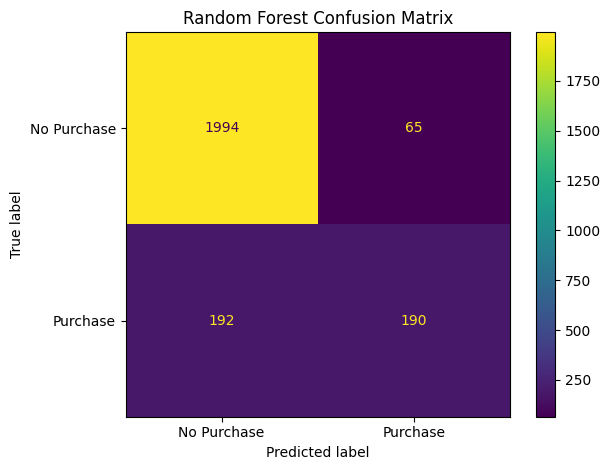

In [11]:
# Confusion matrix: Random Forest baseline.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_predictions['Random Forest'],
    display_labels=['No Purchase', 'Purchase'],
    values_format='d',
)
plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '03_random_forest_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

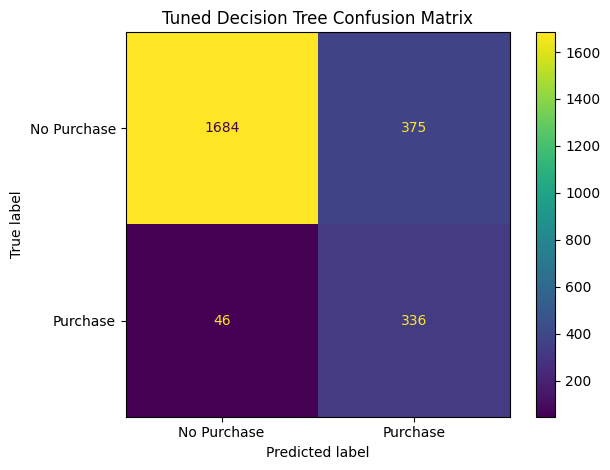

In [12]:
# Confusion matrix: tuned Decision Tree.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_predictions['Tuned Decision Tree'],
    display_labels=['No Purchase', 'Purchase'],
    values_format='d',
)
plt.title('Tuned Decision Tree Confusion Matrix')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '04_tuned_decision_tree_confusion_matrix.png', dpi=180, bbox_inches='tight')
plt.show()

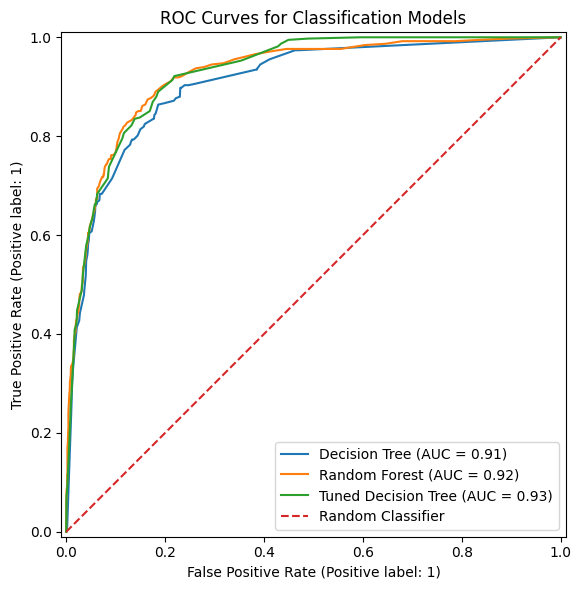

In [13]:
# ROC curves for all classification models.
plt.figure(figsize=(8, 6))
axis = plt.gca()
for model_name, probabilities in model_probabilities.items():
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities,
        name=model_name,
        ax=axis,
    )
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.title('ROC Curves for Classification Models')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / '05_classification_roc_curves.png', dpi=180, bbox_inches='tight')
plt.show()

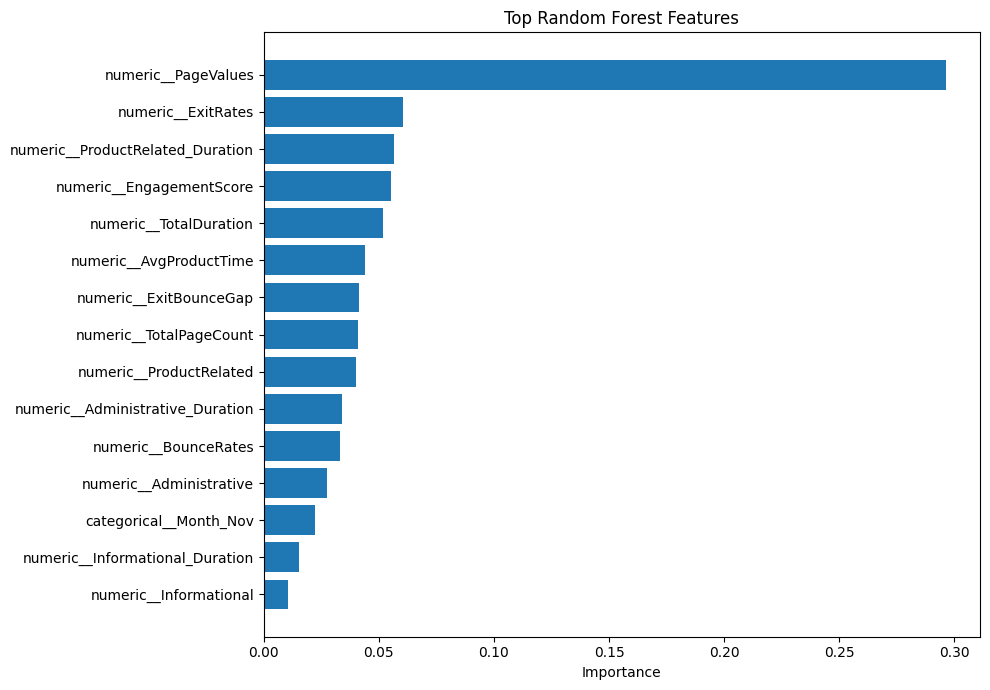

,Feature,Importance
8,numeric__PageValues,0.2963
7,numeric__ExitRates,0.0604
5,numeric__ProductRelated_Duration,0.0565
13,numeric__EngagementScore,0.0552
11,numeric__TotalDuration,0.0516
12,numeric__AvgProductTime,0.0439
14,numeric__ExitBounceGap,0.0415
10,numeric__TotalPageCount,0.0410
4,numeric__ProductRelated,0.0401
1,numeric__Administrative_Duration,0.0341


In [14]:
# Inspect the fitted Random Forest's most influential encoded features.
best_preprocessor = random_forest.named_steps['preprocessor']
best_classifier = random_forest.named_steps['model']
feature_names = best_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_classifier.feature_importances_,
}).sort_values('Importance', ascending=False)
feature_importance.to_csv(OUTPUT_DIR / 'random_forest_feature_importance.csv', index=False)

top_features = feature_importance.head(15).sort_values('Importance')
plt.figure(figsize=(10, 7))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.xlabel('Importance')
plt.title('Top Random Forest Features')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '06_random_forest_feature_importance.png', dpi=180, bbox_inches='tight')
plt.show()

display(feature_importance.head(15))

In [15]:
# Print an evidence-based classification summary.
best_row = classification_metrics.iloc[0]
best_name = best_row['Model']
best_confusion = confusion_matrix(y_test, model_predictions[best_name])
tn, fp, fn, tp = best_confusion.ravel()

print(f'Best F1 model: {best_name}')
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"F1 score: {best_row['F1 Score']:.4f}")
print(f"ROC-AUC: {best_row['ROC-AUC']:.4f}")
print(f'True negatives: {tn:,}; false positives: {fp:,}; false negatives: {fn:,}; true positives: {tp:,}')
print('\nInterpretation: the tuned tree balances purchase detection and overall discrimination, while the Random Forest provides a strong ensemble benchmark.')

Best F1 model: Decision Tree
Accuracy: 0.8472
F1 score: 0.6213
ROC-AUC: 0.9072
True negatives: 1,762; false positives: 297; false negatives: 76; true positives: 306

Interpretation: the tuned tree balances purchase detection and overall discrimination, while the Random Forest provides a strong ensemble benchmark.


## 3. K-Means clustering

Clustering is performed without using `Revenue`. The purpose is to discover naturally occurring session-behaviour groups. Count, duration, and page-value fields are log-transformed to reduce extreme right skew, then all clustering features are standardized.

The number of clusters is selected by comparing silhouette scores for `k = 2` through `k = 6`.

In [16]:
CLUSTER_FEATURES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
]
LOG_CLUSTER_FEATURES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration', 'PageValues',
]

cluster_data = df[CLUSTER_FEATURES].copy()
for column in LOG_CLUSTER_FEATURES:
    cluster_data[column] = np.log1p(cluster_data[column])

cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_data)

silhouette_rows = []
for k in range(2, 7):
    candidate_model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE,
    )
    candidate_labels = candidate_model.fit_predict(cluster_scaled)
    score = silhouette_score(
        cluster_scaled,
        candidate_labels,
        sample_size=min(4000, len(df)),
        random_state=RANDOM_STATE,
    )
    silhouette_rows.append({'Clusters': k, 'Silhouette Score': score})

silhouette_results = pd.DataFrame(silhouette_rows)
silhouette_results.to_csv(OUTPUT_DIR / 'silhouette_scores.csv', index=False)
display(silhouette_results)

,Clusters,Silhouette Score
0,2,0.2647
1,3,0.3634
2,4,0.3205
3,5,0.3462
4,6,0.3527


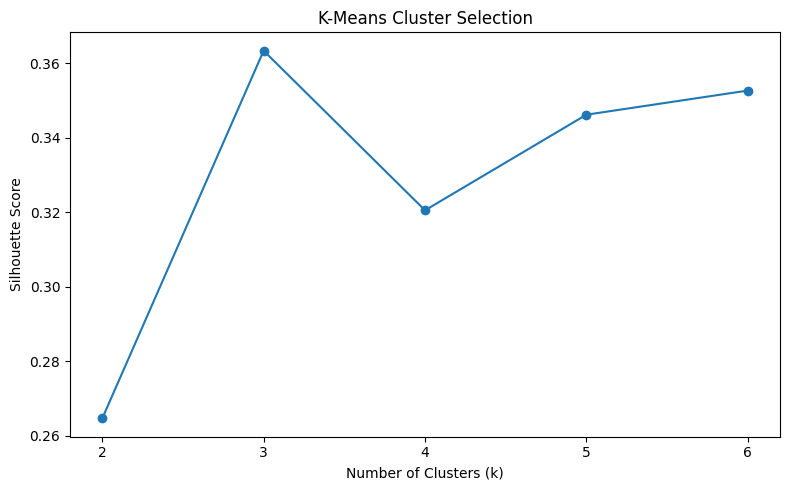

In [17]:
# Visualize the silhouette comparison.
plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_results['Clusters'],
    silhouette_results['Silhouette Score'],
    marker='o',
)
plt.xticks(silhouette_results['Clusters'])
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('K-Means Cluster Selection')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '07_kmeans_silhouette_scores.png', dpi=180, bbox_inches='tight')
plt.show()

In [18]:
# Select the k with the highest silhouette score and fit the final model.
best_k = int(
    silhouette_results.loc[
        silhouette_results['Silhouette Score'].idxmax(), 'Clusters'
    ]
)

kmeans = KMeans(
    n_clusters=best_k,
    n_init=30,
    random_state=RANDOM_STATE,
)
cluster_ids = kmeans.fit_predict(cluster_scaled)
df['Cluster_ID'] = cluster_ids

# Assign readable names based on objective profile characteristics.
raw_profile = df.groupby('Cluster_ID')[CLUSTER_FEATURES].mean()
brief_cluster = raw_profile['BounceRates'].idxmax()
engaged_cluster = raw_profile['ProductRelated_Duration'].idxmax()
remaining_clusters = [
    cluster_id for cluster_id in raw_profile.index
    if cluster_id not in {brief_cluster, engaged_cluster}
]

cluster_name_map = {
    int(brief_cluster): 'Brief High-Bounce Sessions',
    int(engaged_cluster): 'Highly Engaged Researchers',
}
for cluster_id in remaining_clusters:
    cluster_name_map[int(cluster_id)] = 'Typical Product Browsers'

df['Cluster'] = df['Cluster_ID'].map(cluster_name_map)

print(f'Selected number of clusters: {best_k}')
print('Cluster-name mapping:', cluster_name_map)

Selected number of clusters: 3
Cluster-name mapping: {2: 'Brief High-Bounce Sessions', 0: 'Highly Engaged Researchers', 1: 'Typical Product Browsers'}


In [19]:
# Profile each cluster. Revenue is shown only after clustering as an external
# business outcome; it was not used to form the clusters.
cluster_profiles = df.groupby('Cluster').agg(
    Sessions=('Revenue', 'size'),
    Purchase_Rate=('Revenue', 'mean'),
    Administrative_Pages=('Administrative', 'mean'),
    Informational_Pages=('Informational', 'mean'),
    Product_Pages=('ProductRelated', 'mean'),
    Product_Duration=('ProductRelated_Duration', 'mean'),
    Bounce_Rate=('BounceRates', 'mean'),
    Exit_Rate=('ExitRates', 'mean'),
    Page_Value=('PageValues', 'mean'),
).sort_values('Product_Duration', ascending=False)

cluster_profiles.to_csv(OUTPUT_DIR / 'cluster_profiles.csv')
display(cluster_profiles)

,Sessions,Purchase_Rate,Administrative_Pages,Informational_Pages,Product_Pages,Product_Duration,Bounce_Rate,Exit_Rate,Page_Value
Cluster,,,,,,,,,
Highly Engaged Researchers,2310,0.2455,5.1645,2.5264,66.5801,"2,632.6841",0.0073,0.0217,8.6254
Typical Product Browsers,9021,0.1482,1.8382,0.0394,26.0653,955.1768,0.0097,0.0330,5.8408
Brief High-Bounce Sessions,874,0.0046,0.0389,0.0206,2.4966,37.8386,0.1654,0.1810,0.0000


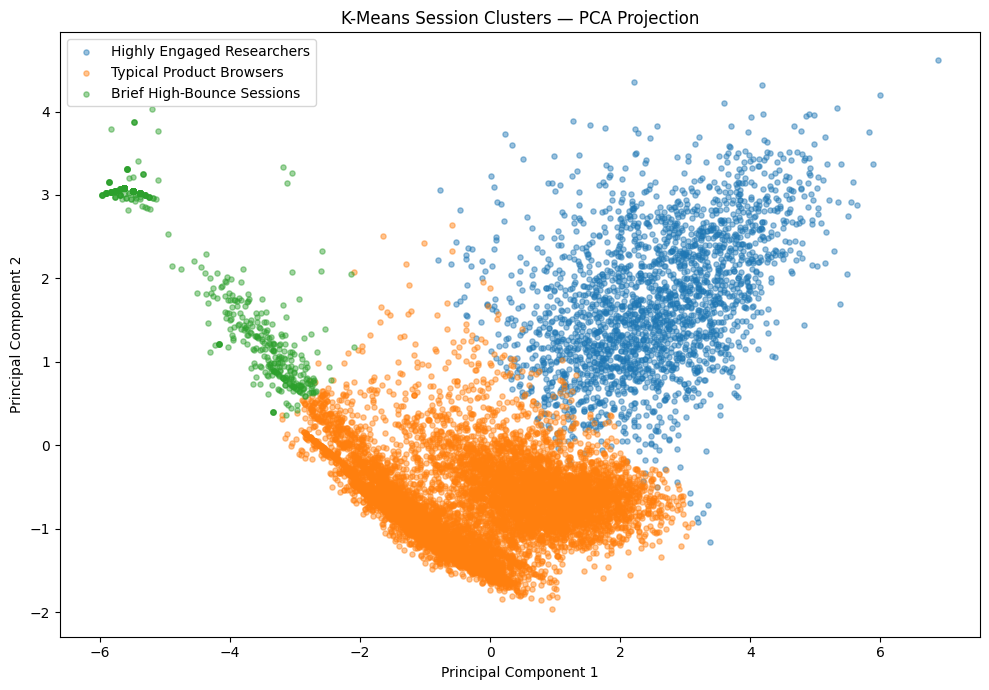

PCA variance represented: 60.53%


In [20]:
# Two-dimensional PCA projection for visualization only.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_pca = pca.fit_transform(cluster_scaled)

pca_frame = pd.DataFrame({
    'PC1': cluster_pca[:, 0],
    'PC2': cluster_pca[:, 1],
    'Cluster': df['Cluster'],
})

plt.figure(figsize=(10, 7))
for cluster_name in cluster_profiles.index:
    group = pca_frame[pca_frame['Cluster'] == cluster_name]
    plt.scatter(
        group['PC1'],
        group['PC2'],
        s=14,
        alpha=0.45,
        label=cluster_name,
    )
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Session Clusters — PCA Projection')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / '08_kmeans_pca_clusters.png', dpi=180, bbox_inches='tight')
plt.show()

print(f'PCA variance represented: {pca.explained_variance_ratio_.sum():.2%}')

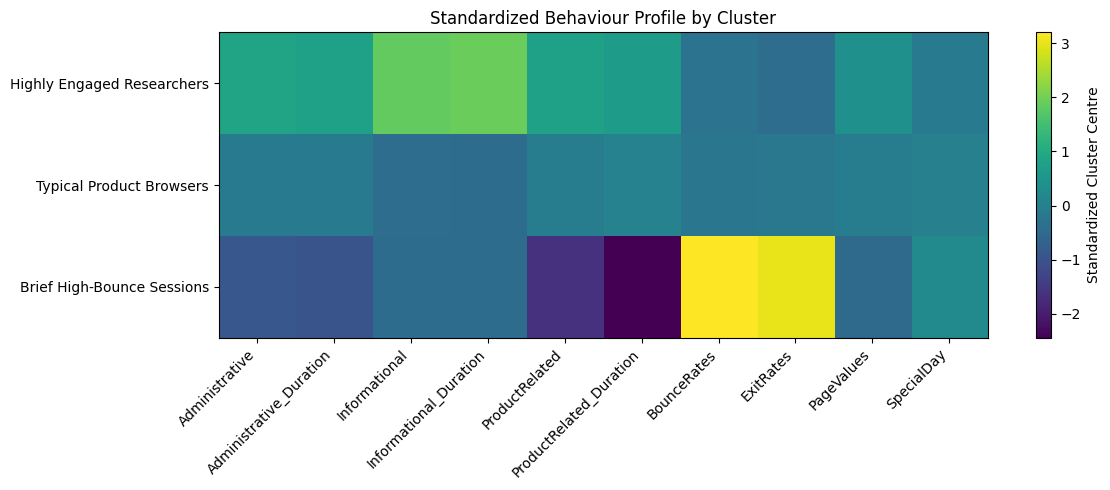

In [21]:
# Standardized cluster-centre profile heatmap.
centre_frame = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=CLUSTER_FEATURES,
    index=[cluster_name_map[int(i)] for i in range(best_k)],
)
centre_frame = centre_frame.loc[cluster_profiles.index]

plt.figure(figsize=(12, 5))
image = plt.imshow(centre_frame, aspect='auto')
plt.colorbar(image, label='Standardized Cluster Centre')
plt.xticks(range(len(CLUSTER_FEATURES)), CLUSTER_FEATURES, rotation=45, ha='right')
plt.yticks(range(len(centre_frame)), centre_frame.index)
plt.title('Standardized Behaviour Profile by Cluster')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '09_cluster_profile_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()

In [22]:
# Generate a concise interpretation from the measured cluster profiles.
for cluster_name, row in cluster_profiles.iterrows():
    print(
        f"{cluster_name}: {int(row['Sessions']):,} sessions, "
        f"{row['Purchase_Rate']:.1%} purchase rate, "
        f"{row['Product_Pages']:.1f} average product pages, "
        f"{row['Bounce_Rate']:.3f} average bounce rate."
    )

Highly Engaged Researchers: 2,310 sessions, 24.5% purchase rate, 66.6 average product pages, 0.007 average bounce rate.
Typical Product Browsers: 9,021 sessions, 14.8% purchase rate, 26.1 average product pages, 0.010 average bounce rate.
Brief High-Bounce Sessions: 874 sessions, 0.5% purchase rate, 2.5 average product pages, 0.165 average bounce rate.


## 4. Apriori association rule mining

The source data contains one row per session rather than individual products in a basket. Therefore, transactions are constructed from meaningful **session-level Boolean conditions**, such as positive page value, high product engagement, low bounce rate, visitor type, weekend activity, month, cluster membership, and purchase outcome.

A compact Apriori implementation is included below so the notebook has no dependency on `mlxtend`. It mines frequent itemsets up to length three and produces rules with support, confidence, lift, leverage, and conviction.

In [23]:
# Convert continuous and categorical session characteristics into Boolean items.
positive_page_values = df.loc[df['PageValues'] > 0, 'PageValues']

transactions = pd.DataFrame(index=df.index)
transactions['Revenue_Yes'] = df['Revenue']
transactions['Revenue_No'] = ~df['Revenue']
transactions['PageValue_Positive'] = df['PageValues'] > 0
transactions['PageValue_High'] = (
    df['PageValues'] >= positive_page_values.quantile(0.75)
)
transactions['ProductPages_High'] = (
    df['ProductRelated'] >= df['ProductRelated'].quantile(0.75)
)
transactions['ProductDuration_High'] = (
    df['ProductRelated_Duration'] >= df['ProductRelated_Duration'].quantile(0.75)
)
transactions['Bounce_Low'] = (
    df['BounceRates'] <= df['BounceRates'].quantile(0.25)
)
transactions['Bounce_High'] = (
    df['BounceRates'] >= df['BounceRates'].quantile(0.75)
)
transactions['Exit_Low'] = (
    df['ExitRates'] <= df['ExitRates'].quantile(0.25)
)
transactions['Exit_High'] = (
    df['ExitRates'] >= df['ExitRates'].quantile(0.75)
)
transactions['Administrative_Visited'] = df['Administrative'] > 0
transactions['Informational_Visited'] = df['Informational'] > 0
transactions['New_Visitor'] = df['VisitorType'].eq('New_Visitor')
transactions['Returning_Visitor'] = df['VisitorType'].eq('Returning_Visitor')
transactions['Weekend'] = df['Weekend']
transactions['Month_Nov'] = df['Month'].eq('Nov')
transactions['SpecialDay_Near'] = df['SpecialDay'] > 0

# Include discovered clusters as transaction items.
for cluster_name in cluster_profiles.index:
    item_name = 'Cluster_' + cluster_name.replace(' ', '_').replace('-', '_')
    transactions[item_name] = df['Cluster'].eq(cluster_name)

item_support = transactions.mean().sort_values(ascending=False).to_frame('Support')
display(item_support)

,Support
Returning_Visitor,0.8546
Revenue_No,0.8437
Cluster_Typical_Product_Browsers,0.7391
Administrative_Visited,0.5376
Bounce_Low,0.4521
ProductPages_High,0.2545
Bounce_High,0.2506
ProductDuration_High,0.2501
Exit_High,0.2501
Exit_Low,0.2501


In [24]:
def apriori_frequent_itemsets(
    binary_data: pd.DataFrame,
    min_support: float = 0.03,
    max_length: int = 3,
):
    """Mine frequent itemsets with Apriori candidate generation and pruning."""
    support_lookup = {}
    current_level = []

    # Frequent one-item sets.
    for column in binary_data.columns:
        itemset = frozenset([column])
        support = float(binary_data[column].mean())
        if support >= min_support:
            support_lookup[itemset] = support
            current_level.append(itemset)

    itemset_length = 2
    while current_level and itemset_length <= max_length:
        candidates = set()

        # Join frequent (k-1)-itemsets to create k-item candidates.
        for left, right in combinations(current_level, 2):
            candidate = left | right
            if len(candidate) != itemset_length:
                continue

            # Apriori pruning: every (k-1) subset must already be frequent.
            all_subsets_frequent = all(
                frozenset(subset) in support_lookup
                for subset in combinations(candidate, itemset_length - 1)
            )
            if all_subsets_frequent:
                candidates.add(candidate)

        next_level = []
        for candidate in candidates:
            support = float(binary_data[list(candidate)].all(axis=1).mean())
            if support >= min_support:
                support_lookup[candidate] = support
                next_level.append(candidate)

        current_level = next_level
        itemset_length += 1

    frequent_itemsets = pd.DataFrame([
        {
            'Itemset': tuple(sorted(itemset)),
            'Length': len(itemset),
            'Support': support,
        }
        for itemset, support in support_lookup.items()
    ]).sort_values(['Length', 'Support'], ascending=[True, False])

    return frequent_itemsets.reset_index(drop=True), support_lookup


def generate_association_rules(
    support_lookup: dict,
    min_confidence: float = 0.55,
    min_lift: float = 1.10,
):
    """Create association rules and standard rule-quality statistics."""
    rows = []

    for itemset, itemset_support in support_lookup.items():
        if len(itemset) < 2:
            continue

        items = list(itemset)
        for antecedent_size in range(1, len(items)):
            for antecedent_tuple in combinations(items, antecedent_size):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent

                antecedent_support = support_lookup.get(antecedent)
                consequent_support = support_lookup.get(consequent)
                if antecedent_support is None or consequent_support is None:
                    continue

                confidence = itemset_support / antecedent_support
                lift = confidence / consequent_support

                if confidence < min_confidence or lift < min_lift:
                    continue

                leverage = itemset_support - antecedent_support * consequent_support
                conviction = (
                    (1 - consequent_support) / (1 - confidence)
                    if confidence < 1 else np.inf
                )

                rows.append({
                    'Antecedent': ' AND '.join(sorted(antecedent)),
                    'Consequent': ' AND '.join(sorted(consequent)),
                    'Support': itemset_support,
                    'Confidence': confidence,
                    'Lift': lift,
                    'Leverage': leverage,
                    'Conviction': conviction,
                })

    if not rows:
        return pd.DataFrame(columns=[
            'Antecedent', 'Consequent', 'Support', 'Confidence',
            'Lift', 'Leverage', 'Conviction'
        ])

    return pd.DataFrame(rows).sort_values(
        ['Lift', 'Confidence', 'Support'],
        ascending=False,
    ).reset_index(drop=True)

In [25]:
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.55
MIN_LIFT = 1.10

frequent_itemsets, support_lookup = apriori_frequent_itemsets(
    transactions,
    min_support=MIN_SUPPORT,
    max_length=3,
)
association_rules = generate_association_rules(
    support_lookup,
    min_confidence=MIN_CONFIDENCE,
    min_lift=MIN_LIFT,
)

purchase_rules = association_rules[
    association_rules['Consequent'].eq('Revenue_Yes')
].copy()

frequent_itemsets.to_csv(OUTPUT_DIR / 'frequent_itemsets.csv', index=False)
association_rules.to_csv(OUTPUT_DIR / 'association_rules.csv', index=False)
purchase_rules.to_csv(OUTPUT_DIR / 'purchase_association_rules.csv', index=False)

print(f'Frequent itemsets found: {len(frequent_itemsets):,}')
print(f'Association rules found: {len(association_rules):,}')
print(f'Rules predicting purchase: {len(purchase_rules):,}')
display(purchase_rules.head(15))

Frequent itemsets found: 484
Association rules found: 371
Rules predicting purchase: 10


,Antecedent,Consequent,Support,Confidence,Lift,Leverage,Conviction
6,Bounce_Low AND PageValue_High,Revenue_Yes,0.0349,0.8765,5.6070,0.0287,6.8337
8,Cluster_Typical_Product_Browsers AND PageValue...,Revenue_Yes,0.0352,0.8190,5.2392,0.0285,4.6624
10,PageValue_High,Revenue_Yes,0.0437,0.7804,4.9919,0.0349,3.8415
11,PageValue_High AND PageValue_Positive,Revenue_Yes,0.0437,0.7804,4.9919,0.0349,3.8415
21,Bounce_Low AND PageValue_Positive,Revenue_Yes,0.0714,0.7315,4.6795,0.0562,3.1427
50,Exit_Low AND PageValue_Positive,Revenue_Yes,0.0604,0.6724,4.3015,0.0463,2.5757
51,Month_Nov AND PageValue_Positive,Revenue_Yes,0.0422,0.6594,4.2181,0.0322,2.4771
55,Cluster_Typical_Product_Browsers AND PageValue...,Revenue_Yes,0.0874,0.6310,4.0363,0.0658,2.2863
69,PageValue_Positive AND Weekend,Revenue_Yes,0.0326,0.5827,3.7275,0.0239,2.0218
74,PageValue_Positive,Revenue_Yes,0.1260,0.5634,3.6037,0.0910,1.9322


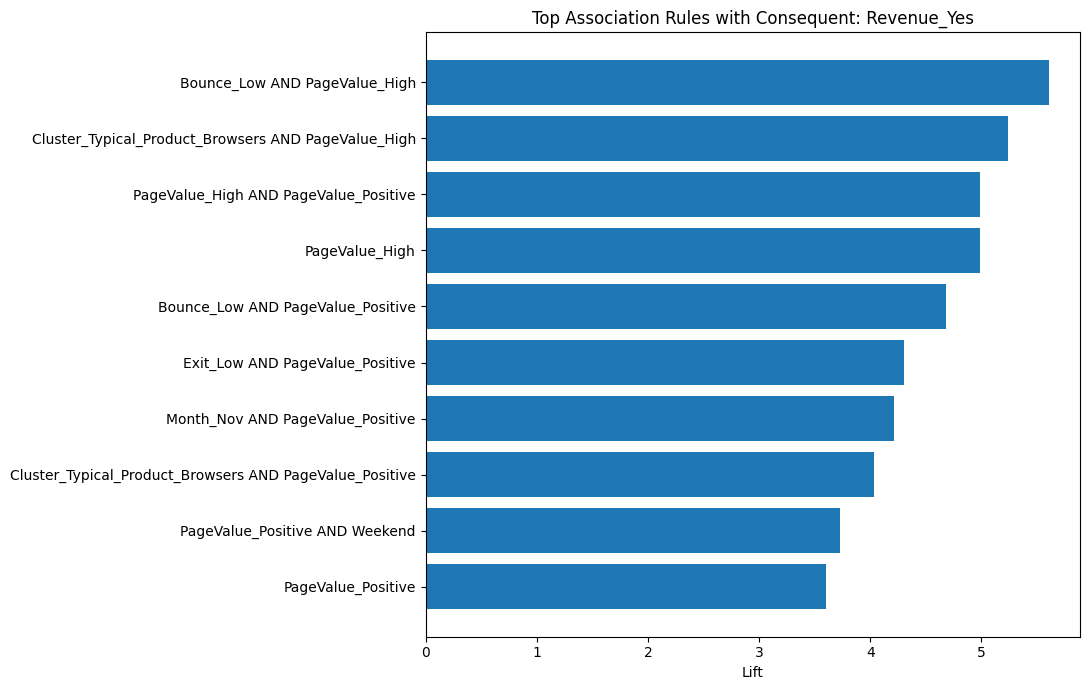

In [26]:
# Visualize the strongest purchase rules by lift.
top_purchase_rules = purchase_rules.head(10).sort_values('Lift')

plt.figure(figsize=(11, 7))
plt.barh(top_purchase_rules['Antecedent'], top_purchase_rules['Lift'])
plt.xlabel('Lift')
plt.title('Top Association Rules with Consequent: Revenue_Yes')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '10_top_purchase_association_rules.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Practical application of discovered patterns

The results support several real-world e-commerce actions:

- **Purchase-intent scoring:** Use the best-performing classifier to prioritize sessions for personalized offers, live assistance, or remarketing. The operating threshold should be selected according to the cost of missing a likely buyer versus contacting a non-buyer.
- **High-engagement sessions:** Visitors who research many product and information pages are strong candidates for comparison tools, product recommendations, saved carts, and detailed content.
- **Typical product browsers:** This largest group can be guided with clearer calls to action, social proof, shipping information, and personalized recommendations.
- **Brief high-bounce sessions:** Improve landing-page relevance, site speed, mobile usability, and navigation for sessions that leave quickly and rarely purchase.
- **Association rules:** Rules connecting positive/high page value, low bounce/exit behaviour, November traffic, and purchase can guide campaign timing and trigger-based personalization.

### Important limitation

`PageValues` is extremely predictive, but it may be computed late in the session and may not be available at the earliest intervention point. A production implementation should validate when the feature becomes available and compare models with and without it before deployment.

In [27]:
# Final concise summary, generated from the actual notebook results.
best_classifier_row = classification_metrics.iloc[0]
lowest_conversion_cluster = cluster_profiles['Purchase_Rate'].idxmin()
highest_conversion_cluster = cluster_profiles['Purchase_Rate'].idxmax()
strongest_purchase_rule = purchase_rules.iloc[0]

print('FINAL SUMMARY')
print('-' * 70)
print(
    f"Best classifier: {best_classifier_row['Model']} — "
    f"Accuracy {best_classifier_row['Accuracy']:.3f}, "
    f"F1 {best_classifier_row['F1 Score']:.3f}, "
    f"ROC-AUC {best_classifier_row['ROC-AUC']:.3f}."
)
print(
    f"Highest-conversion cluster: {highest_conversion_cluster} "
    f"({cluster_profiles.loc[highest_conversion_cluster, 'Purchase_Rate']:.1%})."
)
print(
    f"Lowest-conversion cluster: {lowest_conversion_cluster} "
    f"({cluster_profiles.loc[lowest_conversion_cluster, 'Purchase_Rate']:.1%})."
)
print(
    f"Strongest displayed purchase rule: {strongest_purchase_rule['Antecedent']} "
    f"→ Revenue_Yes, confidence {strongest_purchase_rule['Confidence']:.1%}, "
    f"lift {strongest_purchase_rule['Lift']:.2f}."
)
print('\nAll figures and result tables have been saved for GitHub submission.')

FINAL SUMMARY
----------------------------------------------------------------------
Best classifier: Decision Tree — Accuracy 0.847, F1 0.621, ROC-AUC 0.907.
Highest-conversion cluster: Highly Engaged Researchers (24.5%).
Lowest-conversion cluster: Brief High-Bounce Sessions (0.5%).
Strongest displayed purchase rule: Bounce_Low AND PageValue_High → Revenue_Yes, confidence 87.7%, lift 5.61.

All figures and result tables have been saved for GitHub submission.


## Reference

Sakar, C., & Kastro, Y. (2018). *Online Shoppers Purchasing Intention Dataset* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q